# Sieci Neuronowe
## Ćwiczenie 1 - analiza eksploracyjna danych

Źródło danych: https://archive.ics.uci.edu/dataset/45/heart+disease

Plan:
1. Import bibliotek
2. Wczytanie danych (Cleveland)
3. Przegląd struktury danych
4. Zbalansowanie klas (oryginalne i binarne targety)
5. Statystyki cech liczbowych
6. Rozkłady cech liczbowych (histogramy + Q-Q, test Shapiro)
7. Rozkłady cech kategorycznych (tabele + chi-kwadrat)
8. Braki danych i strategie imputacji
9. Preprocessing i macierz cech (one-hot + standaryzacja)
10. Podsumowanie

## 1. Import bibliotek
Pandas, NumPy, SciPy, Matplotlib, Seaborn, Scikit-learn.

In [3]:
# Importy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
# wwarnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler

# Ustawienia wykresów i wyświetlania
plt.style.use('default')
sns.set_palette('husl')
pd.set_option('display.max_columns', None) # Na ten moment niepotrzebne, ale na laptopie może być
pd.set_option('display.width', None) # Analogicznie

print('Importy OK')

Importy OK


## 2. Wczytanie danych
Pobieramy plik podany w ćwiczeniu i nadajemy kolumną nazwy.

In [4]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']

data = pd.read_csv(url, names=columns, na_values='?') # ? == NA (do zapamiętania atrybut metody)
print('Wczytano dane:', data.shape)
print('Podgląd:')
display(data.head())

Wczytano dane: (303, 14)
Podgląd:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Komentarz
- Po udanym wczytaniu danych otrzymujemy zestaw 303 próbek, z czego każda posiada 14 atrybutów liczbowych i kategorii. Zdaje się, że może być to ilość nieywstarczająca w późniejszym uczeniu maszynowym. Konieczne będzie dodanie danych (może prze generację na podstawie obecnych).
- Kolejnym zmartwieniem jest, czy 303 próbki będą stanowiły dobrą reprezentację szerszej populacji.
- Część kolumn to kategorie zakodowane liczbowo. (target, thal, slope (?))

## 3. Przegląd struktury danych
Kształt, typy danych, pierwsze wiersze i statystyki.

In [5]:
print('Kształt:', data.shape)
print('\nTypy danych:')
print(data.dtypes)

print('\nPierwsze 10 wierszy:')
display(data.head(10))

print('\nStatystyki opisowe:')
display(data.describe(include='all'))

print('\nInfo:')
print(data.info())

Kształt: (303, 14)

Typy danych:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Pierwsze 10 wierszy:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1



Statystyki opisowe:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


### Komentarz
- Widzimy braki danych w kolumnach `ca` i `thal` (patrz sekcja 8).
- Typy: część kolumn numerycznych ma rozkłady odchylone (sprawdzimy normalność w sekcji 6). Duża różnica mean-median. Asymetria kwartyli. Maxy daleko od kwartla 3 (Np. przy age)
- Skala cech liczbowych jest różna, co uzasadnia późniejszą standaryzację.

## 4. Zbalansowanie klas
Sprawdzamy rozkład klas dla oryginalnego targetu (0..4) oraz wersji binarnej (0/1). Wersja binarna była pomysłem ChatGPT 5.

Rozkład oryginalnego targetu:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
target
0    54.13
1    18.15
2    11.88
3    11.55
4     4.29
Name: count, dtype: float64

Rozkład binarny targetu:
target_binary
0    164
1    139
Name: count, dtype: int64
target_binary
0    54.13
1    45.87
Name: count, dtype: float64


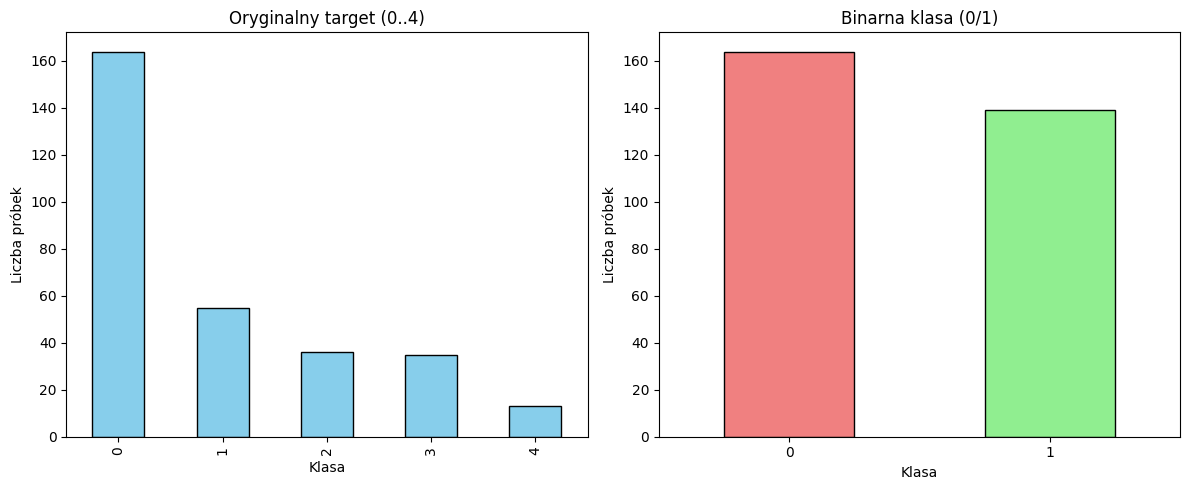

Stosunek mniejszej do większej klasy: 0.848


In [ ]:
# Tworzymy binarny target: 0 = brak choroby, 1 = obecność choroby
# Oryginalny target ma 5 klas (0..4); do klasyfikacji binarnej spłaszczamy go do 0/1
# zgodnie z konwencją UCI: wartości > 0 traktujemy jako obecność choroby.
data['target_binary'] = (data['target'] > 0).astype(int)

# Rozkład oryginalnych pięciu klas
print('Rozkład oryginalnego targetu:')
orig_counts = data['target'].value_counts().sort_index()
print(orig_counts)
print((orig_counts/len(data)*100).round(2)) # Procenty

# Rozkład klas po binaryzacji
print('\nRozkład binarny targetu:')
bin_counts = data['target_binary'].value_counts().sort_index()
print(bin_counts)
print((bin_counts/len(data)*100).round(2)) # Procenty

# Wykresy
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Oryginalny target
orig_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Oryginalny target (0..4)')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Liczba próbek')

# Binarna wersja targetu
bin_counts.plot(kind='bar', ax=axes[1], color=['lightcoral','lightgreen'], edgecolor='black')
axes[1].set_title('Binarna klasa (0/1)')
axes[1].set_xlabel('Klasa')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_xticklabels(['0','1'], rotation=0)

plt.tight_layout()
plt.show()

# Prosty wskaźnik balansu klas: min/max. 1.0 oznacza idealne zbalansowanie,
# im mniejszy wynik, tym większa nierównowaga (potrzeba stratyfikacji/ważenia).
ratio = min(bin_counts)/max(bin_counts)
print(f"Stosunek mniejszej do większej klasy: {ratio:.3f}")

### Komentarz
- Oryginalny target jest bardziej rozproszony i trudniejszy do modelowania przy tak małej próbie. Widzimy znaczącą przewagę klasy 0 (osób zdrowych). Natomiast, warto jest rozważyć złączenie klas 1-4.
- Wersja binarna ma umiarkowaną nierównowagę. Warto rozważyć ewentualnie ważenie klas.
- Wykresy pokazują przewagę klasy z chorobą i bez w stosunkowo zbalansowanym podziale (ok 54% do 46%)

## 5. Statystyki cech liczbowych
Średnie, odchylenia, korelacje.

Cechy liczbowe: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Cechy kategoryczne: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Statystyki opisowe (liczbowe):


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


,cecha,srednia,std,mediana,min,max
0,age,54.44,9.04,56.0,29.0,77.0
1,trestbps,131.69,17.60,130.0,94.0,200.0
2,chol,246.69,51.78,241.0,126.0,564.0
3,thalach,149.61,22.88,153.0,71.0,202.0
4,oldpeak,1.04,1.16,0.8,0.0,6.2


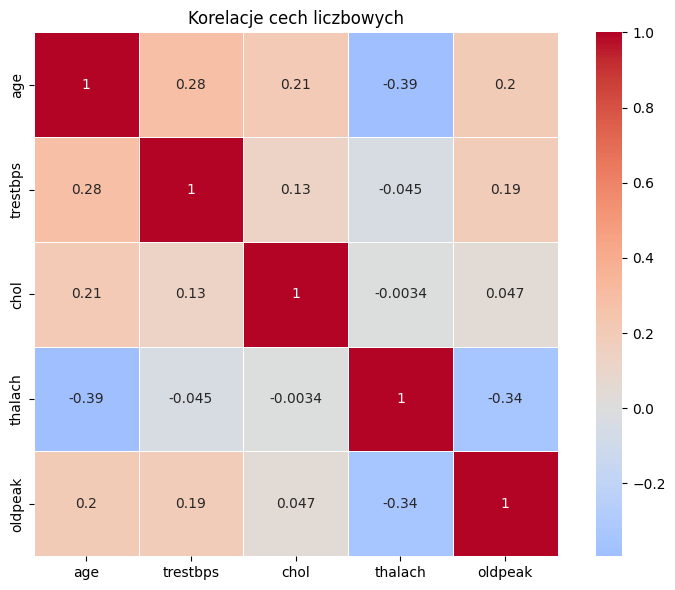

In [7]:
numeric_cols = ['age','trestbps','chol','thalach','oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

print('Cechy liczbowe:', numeric_cols)
print('Cechy kategoryczne:', cat_cols)

print('\nStatystyki opisowe (liczbowe):')
display(data[numeric_cols].describe())

# Średnie i odchylenia
stats_df = pd.DataFrame({
    'cecha': numeric_cols,
    'srednia': [data[c].mean() for c in numeric_cols],
    'std': [data[c].std() for c in numeric_cols],
    'mediana': [data[c].median() for c in numeric_cols],
    'min': [data[c].min() for c in numeric_cols],
    'max': [data[c].max() for c in numeric_cols]
}).round(2)

display(stats_df)

# Korelacje
corr = data[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Korelacje cech liczbowych')
plt.tight_layout(); plt.show()

### Komentarz
- `thalach` (maks. tętno) ujemnie koreluje z `age` i dodatnio z wydolnością, potencjalnie ważna cecha.
- lekkich korelacji ozemy rowniez doszukiwac się w `trestbps` i `age

## 6. Rozkłady cech liczbowych
Histogramy, test Shapiro-Wilka i Q-Q ploty. Q-Q plot został zaproponowany przez ChatGPT 5.

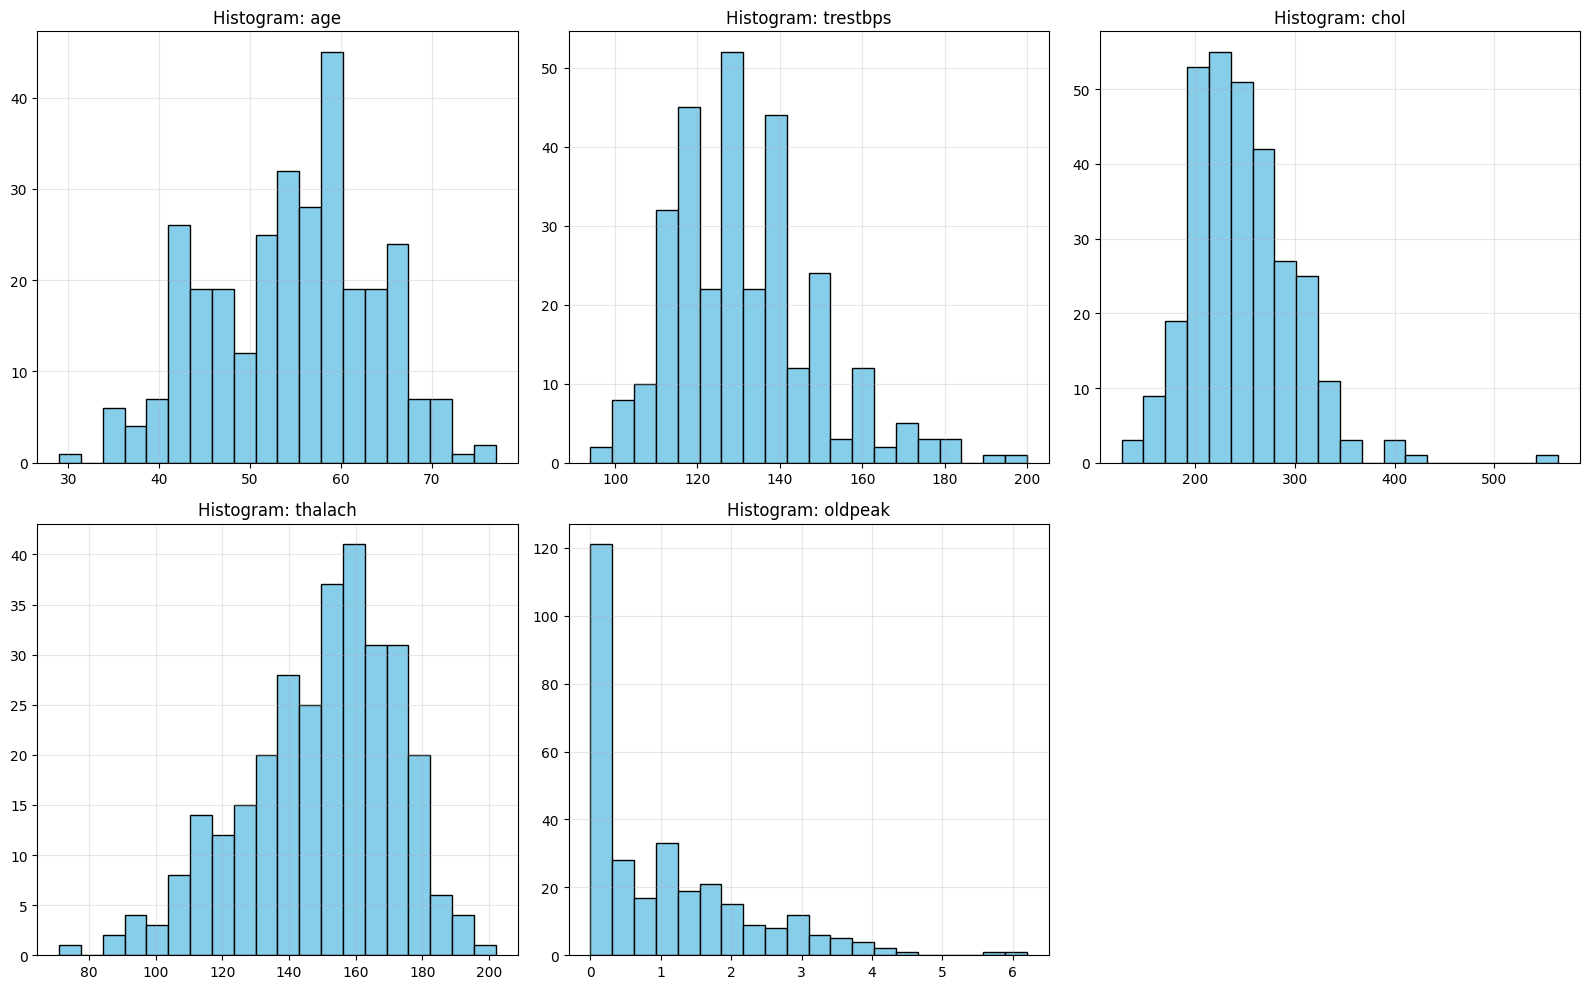

Testy normalności (Shapiro-Wilk)
age       : p=0.006069 -> NIE
trestbps  : p=0.000002 -> NIE
chol      : p=0.000000 -> NIE
thalach   : p=0.000070 -> NIE
oldpeak   : p=0.000000 -> NIE


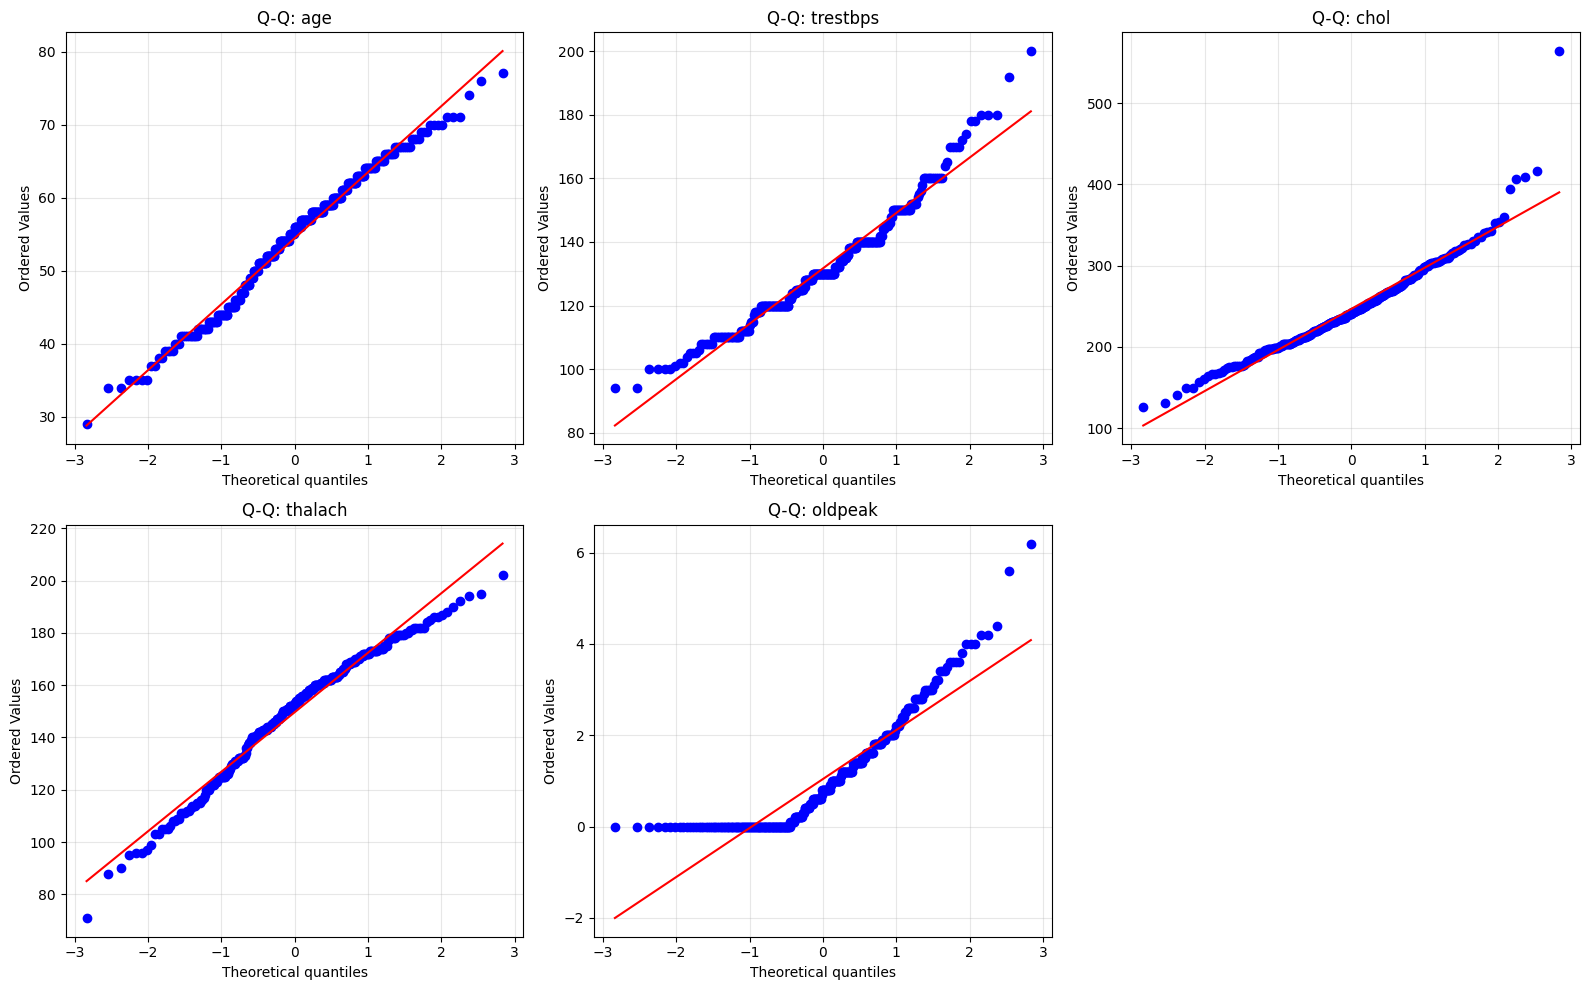

In [6]:
# Histogramy
fig, axes = plt.subplots(2,3, figsize=(16,10))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram: {col}')
    axes[i].grid(True, alpha=0.3)

axes[-1].remove()
plt.tight_layout(); plt.show()

# Test Shapiro-Wilka
print('Testy normalności (Shapiro-Wilk)')
results = []
for col in numeric_cols:
    vals = data[col].dropna()
    stat, p = stats.shapiro(vals) if len(vals) < 5000 else stats.normaltest(vals)
    results.append({'cecha': col, 'p': p, 'normalny': p>0.05})
    print(f"{col:10s}: p={p:.6f} -> {'TAK' if p>0.05 else 'NIE'}")

# Q-Q plots
fig, axes = plt.subplots(2,3, figsize=(16,10))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    stats.probplot(data[col].dropna(), dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q: {col}')
    axes[i].grid(True, alpha=0.3)
axes[-1].remove()
plt.tight_layout(); plt.show()

### Komentarz
- Testy Shapiro wskazują odchylenia od normalności w większości cech.
- Q-Q ploty ujawniają skośność i grube ogony np. w `oldpeak` i `chol` (ale nie jestem pewien co to znaczy).

## 7. Rozkłady cech kategorycznych
Wykresy słupkowe, tabele częstości i test chi-kwadrat równomierności.

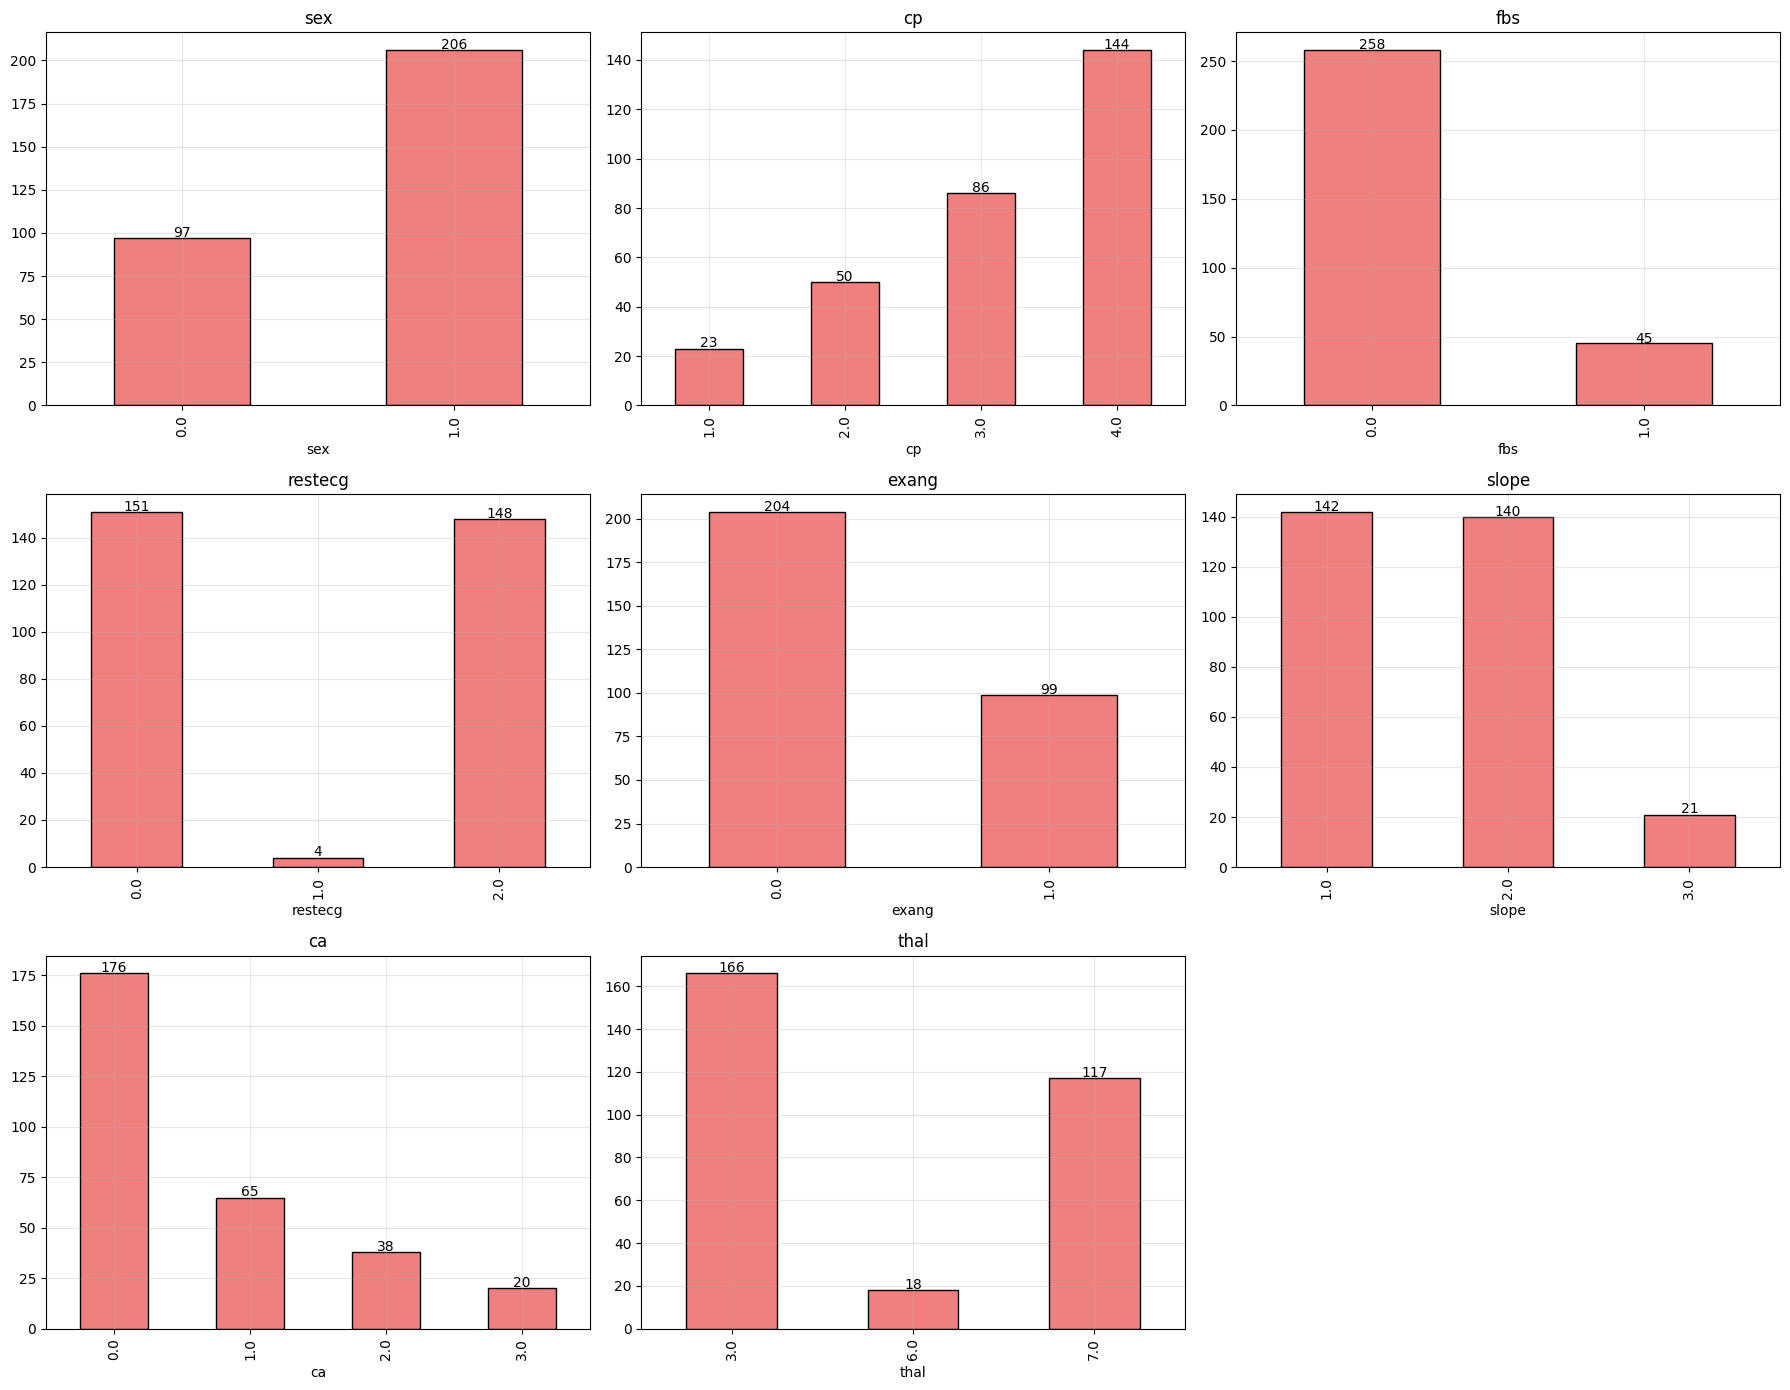

,cecha,kategorie,chi2_p,rownomierny
0,sex,2,3.803480e-10,False
1,cp,4,2.465414e-23,False
2,fbs,2,1.983313e-34,False
3,restecg,3,4.432877e-31,False
4,exang,2,1.618502e-09,False
5,slope,3,2.269668e-21,False
6,ca,4,2.306514e-42,False
7,thal,3,2.484676e-25,False


In [8]:
fig, axes = plt.subplots(3,3, figsize=(18,14))
axes = axes.ravel()
summary = []

for i, col in enumerate(cat_cols):
    vc = data[col].value_counts().sort_index()
    vc.plot(kind='bar', ax=axes[i], color='lightcoral', edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].grid(True, alpha=0.3)
    for j, v in enumerate(vc):
        axes[i].text(j, v+0.5, str(v), ha='center')

    chi2, p = stats.chisquare(vc)
    summary.append({'cecha': col, 'kategorie': len(vc), 'chi2_p': p, 'rownomierny': p>0.05})

axes[-1].remove()
plt.tight_layout(); plt.show()

summary_df = pd.DataFrame(summary)
display(summary_df)

### Komentarz
- Rozkłady kategorii są wyraźnie nierównomierne (np. `sex`, `cp`, `thal`), co potwierdzają niskie p-value w teście chi-kwadrat.
- Scalenie niektrych kategorii może pomóc w prostszych modelach.

## 8. Braki danych i strategia imputacji
Identyfikacja braków i plan ich uzupełnienia.

Cechy z brakami:


,cecha,braki,proc
0,ca,4,1.32
1,thal,2,0.66


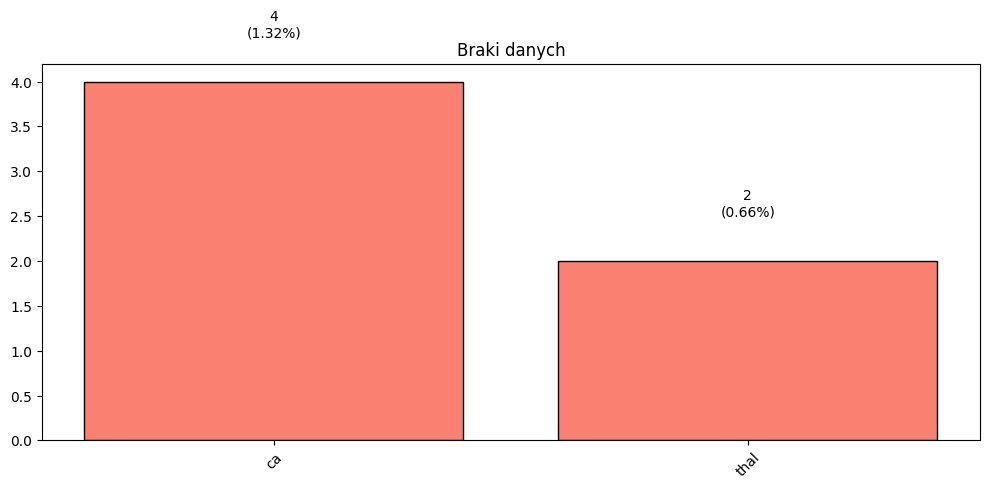

In [9]:
missing = data.isnull().sum().sort_values(ascending=False)
missing_pct = (missing/len(data)*100).round(2)
miss_df = pd.DataFrame({'cecha': missing.index, 'braki': missing.values, 'proc': missing_pct.values})
miss_df = miss_df[miss_df.braki>0]

if len(miss_df):
    print('Cechy z brakami:')
    display(miss_df)
    plt.figure(figsize=(10,5))
    bars = plt.bar(miss_df['cecha'], miss_df['braki'], color='salmon', edgecolor='black')
    plt.xticks(rotation=45)
    plt.title('Braki danych')
    for b, p in zip(bars, miss_df['proc']):
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{int(b.get_height())}\n({p}%)", ha='center')
    plt.tight_layout(); plt.show()
else:
    print('Brak braków danych.')

### Komentarz
- Najwięcej braków: `ca` i `thal` (~1–2%). Procentowo niewiele, więc prosta imputacja jest wystarczająca.
- Dla liczb: mediana jest odporna na wartości odstające.
- Dla kategorii: moda zachowuje spójność semantyczną (bez „nienaturalnych” wartości).

## 9. Preprocessing i macierz cech
Imputacja braków, one-hot encoding i standaryzacja cech liczbowych.

In [9]:
# Kopia danych
X = data.drop(columns=['target'])
y = (data['target']>0).astype(int)

# Imputacja: mediany dla liczbowych, moda dla kategorycznych
X_imputed = X.copy()
for c in numeric_cols:
    if c in X_imputed.columns:
        X_imputed[c] = X_imputed[c].fillna(X_imputed[c].median())
for c in cat_cols:
    if c in X_imputed.columns:
        mode_val = X_imputed[c].mode()
        if len(mode_val):
            X_imputed[c] = X_imputed[c].fillna(mode_val.iloc[0])

# One-hot encoding cech kategorycznych
X_encoded = pd.get_dummies(X_imputed, columns=cat_cols, drop_first=False, prefix=cat_cols)

# Standaryzacja cech liczbowych
scaler = StandardScaler()
num_in_encoded = [c for c in numeric_cols if c in X_encoded.columns]
X_final = X_encoded.copy()
X_final[num_in_encoded] = scaler.fit_transform(X_final[num_in_encoded])

print('Finalny kształt macierzy cech:', X_final.shape)
print('Podgląd:')
display(X_final.head())

X_matrix = X_final.values
y_vector = y.values

print('Typy:', X_matrix.dtype, y_vector.dtype)
feature_names = X_final.columns.tolist()

# Zapamiętujemy obiekty w środowisku
globals()['X_matrix'] = X_matrix
globals()['y_vector'] = y_vector
globals()['feature_names'] = feature_names
globals()['scaler'] = scaler

Finalny kształt macierzy cech: (303, 29)
Podgląd:


,age,trestbps,chol,thalach,oldpeak,target_binary,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,restecg_2.0,exang_0.0,exang_1.0,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0,False,True,True,False,False,False,False,True,False,False,True,True,False,False,False,True,True,False,False,False,False,True,False
1,1.392002,1.611220,0.760415,-1.821905,0.397182,1,False,True,False,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False,False,True,True,False,False
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,1,False,True,False,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0,False,True,False,False,True,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,True,False,False
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,0,True,False,False,True,False,False,True,False,False,False,True,True,False,True,False,False,True,False,False,False,True,False,False


Typy: object int64


### Komentarz
- Zastosowano: medianę (num), modę (kat), one-hot bez redukcji, skalowanie tylko dla num.
- Finalnie otrzymano ~28-29 cech - to rozsądny wymiar dla klasyfikacji binarnej.
- Do modeli: użyj StratifiedKFold lub train_test_split(stratify=y), ew. class_weight='balanced'.

## 10. Podsumowanie
- Zbalansowanie klas, statystyki, rozkłady, braki danych i preprocessing zostały wykonane.
- Wynik: gotowa macierz cech liczbowych do dalszych ćwiczeń (sieci neuronowe).

In [10]:
# Sanity check i finalizacja macierzy cech (bez targetu)
import numpy as np

# 1) Upewnij się, że kolumna targetu nie znajduje się w X
if 'target_binary' in X_final.columns:
    X_final = X_final.drop(columns=['target_binary'])

# 2) Konwersja kolumn bool -> int
bool_cols = X_final.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    X_final[bool_cols] = X_final[bool_cols].astype(int)

# 3) Brak wartości NaN
assert not X_final.isna().any().any(), "W macierzy cech są NaN po finalizacji."

# 4) Zbuduj macierz X oraz wektor y
X_matrix = X_final.to_numpy()
y_vector = y.to_numpy().astype(int)

print(f"Po finalizacji: X_matrix: {X_matrix.shape}, y_vector: {y_vector.shape}")
print(f"Skonwertowano kolumn bool: {len(bool_cols)} -> {bool_cols[:10]}{'...' if len(bool_cols) > 10 else ''}")


Po finalizacji: X_matrix: (303, 28), y_vector: (303,)
Skonwertowano kolumn bool: 23 -> ['sex_0.0', 'sex_1.0', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0', 'fbs_1.0', 'restecg_0.0', 'restecg_1.0']...
